## 驗證T1、T2、T3的衰退曲線

In [1]:
# 匯入所需的函式庫
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.neural_network import MLPRegressor
warnings.filterwarnings("ignore")

In [2]:
# 輔助函式
def load_and_preprocess(base_dir, stage, screws_list):
    df_list = []
    for screws in screws_list:
        file_path = os.path.join(base_dir, f'{stage}\\8000rpm\\{screws}\\{stage}_Group_feature_data.csv')
        if os.path.exists(file_path):
            tmp = pd.read_csv(file_path)
            tmp['screws_cfg'] = screws          # 可保留螺絲數資訊
            df_list.append(tmp)
        else:
            print(f"檔案未找到: {file_path}")
    if not df_list:
        raise ValueError(f"{stage} 無任何檔案被讀取到")
    return pd.concat(df_list, ignore_index=True)

In [3]:
# 加載資料
rootDir = os.getcwd()
df_T1 = load_and_preprocess(f'{rootDir}\\階段1\\myfeature', 'T1', ['8screws'])
df_T2 = load_and_preprocess(f'{rootDir}\\階段2\\myfeature', 'T2', ['8screws'])
df_T3 = load_and_preprocess(f'{rootDir}\\階段3\\myfeature', 'T3', ['8screws'])

In [4]:
# 指派 HI（帶一點波動讓模型不死背）
df_T1['HI'] = np.linspace(1.0, 0.7, len(df_T1)) + np.random.normal(0, 0.2, len(df_T1))
df_T2['HI'] = np.linspace(0.7, 0.3, len(df_T2)) + np.random.normal(0, 0.2, len(df_T2))
df_T3['HI'] = np.linspace(0.3, 0.0, len(df_T3)) + np.random.normal(0, 0.2, len(df_T3))

In [5]:
# 合併與處理
df_all = pd.concat([df_T1, df_T2, df_T3], ignore_index=True)
numeric_cols = df_T1.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('HI')

In [6]:
# 標準化
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_all[numeric_cols])
y = df_all['HI'].clip(0, 1).values  # 確保 HI 不超過 0~1

In [7]:
# 訓練回歸模型
reg = MLPRegressor(hidden_layer_sizes=(32, 32), random_state=42, max_iter=1000)
reg.fit(X_scaled, y)


MLPRegressor(hidden_layer_sizes=(32, 32), max_iter=1000, random_state=42)

In [8]:
# 預測
HI_T1 = reg.predict(scaler.transform(df_T1[numeric_cols])).clip(0, 1)
HI_T2 = reg.predict(scaler.transform(df_T2[numeric_cols])).clip(0, 1)
HI_T3 = reg.predict(scaler.transform(df_T3[numeric_cols])).clip(0, 1)

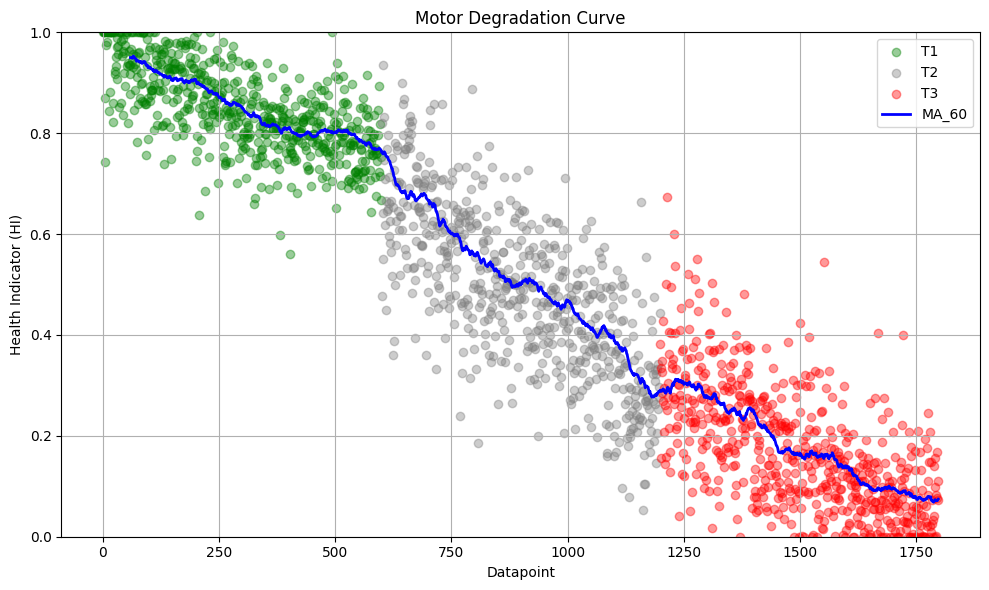

In [9]:
# 繪圖
HI_all = np.concatenate([HI_T1, HI_T2, HI_T3])
dataPoint = np.arange(1, len(HI_all) + 1)

plt.figure(figsize=(10, 6))
plt.scatter(dataPoint[:len(HI_T1)], HI_T1, color='green', label='T1', alpha=0.4)
plt.scatter(dataPoint[len(HI_T1):len(HI_T1)+len(HI_T2)], HI_T2, color='gray', label='T2', alpha=0.4)
plt.scatter(dataPoint[len(HI_T1)+len(HI_T2):], HI_T3, color='red', label='T3', alpha=0.4)

window = 60
moving_avg = pd.Series(HI_all).rolling(window=window).mean()
plt.plot(dataPoint, moving_avg, color='blue', linewidth=2, label=f'MA_{window}')

plt.title('Motor Degradation Curve')
plt.xlabel('Datapoint')
plt.ylabel('Health Indicator (HI)')
plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()